# Virus dynamics and prevalence: grp-SIS vs mean-field SIS

The NetLogo model already updates a **discrete-time homogeneous mean-field SIS** trajectory (`rho-I-mf`, same equation as `update-mean-field-SIS`) alongside the **microscopic grp-SIS** simulation. In the GUI, the plots *Prevalence: grp-SIS vs mean-field* and *Virus dynamics* update while you run `go`.

For **reproducible figures** without clicking through the GUI:

1. Run BehaviorSpace experiment **`08-dynamics-trajectory-ER`** (per-tick metrics, not included in `run_pipeline.py --all` because the CSV is large):
   `python scripts/run_pipeline.py --experiment 08-dynamics-trajectory-ER`
2. This notebook loads `output/raw/08-dynamics-trajectory-ER_table.csv` and plots prevalence and compartment counts.

You can duplicate the experiment block in `netlogo/behaviorspace_experiments.xml` with other `infection-prob` / recovery regimes; adjust `max-ticks` if runs end early (extinction).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "netlogo" / "virus_simulation.nlogox").is_file():
            return p
        if (p / "NetLogo" / "virus_simulation.nlogox").is_file():
            return p
    raise FileNotFoundError(
        "Could not find netlogo/virus_simulation.nlogox. Open the repo root in Cursor."
    )


ROOT = _project_root()
sys.path.insert(0, str(ROOT))

from scripts.analysis_utils import pick_column, read_behaviorspace_table

sns.set_theme(style="whitegrid", context="notebook")
TRAJ_CSV = ROOT / "output" / "raw" / "08-dynamics-trajectory-ER_table.csv"
TRAJ_CSV

WindowsPath('C:/Dossiers/Master AI/Research Methods for AI (IM1312)/RMAI Research Project/output/raw/08-dynamics-trajectory-ER_table.csv')

In [2]:
def discrete_mf_sis_trajectory(
    beta: float,
    recovery_mean: float,
    k_mean: float,
    rho0: float,
    n_steps: int,
) -> np.ndarray:
    """Same one-step Euler as NetLogo `update-mean-field-SIS`: mu = 1/recovery_mean, dt = 1."""
    mu = 1.0 / recovery_mean
    rho = float(rho0)
    out = np.empty(n_steps)
    for t in range(n_steps):
        drho = -mu * rho + beta * k_mean * (1.0 - rho) * rho
        rho = float(np.clip(rho + drho, 0.0, 1.0))
        out[t] = rho
    return out


if not TRAJ_CSV.is_file():
    raise FileNotFoundError(
        f"Missing {TRAJ_CSV}. Run:\n"
        "  python scripts/run_pipeline.py --experiment 08-dynamics-trajectory-ER"
    )

df = read_behaviorspace_table(TRAJ_CSV)
run_col = pick_column(df, "run number", "[run number]")
step_col = pick_column(df, "step", "[step]")
grp_col = pick_column(df, "bs_out_prev_grp", "bs-out-prev-grp")
mf_col = pick_column(df, "bs_out_prev_mf", "bs-out-prev-mf")
s_col = pick_column(df, "bs_out_count_s", "bs-out-count-S")
i_col = pick_column(df, "bs_out_count_i", "bs-out-count-I")
inf_param = pick_column(df, "infection_prob", "infection-prob")
rm_col = pick_column(df, "recovery_mean", "recovery-mean")
deg_col = pick_column(df, "bs_out_mean_degree", "bs-out-mean-degree")

for c in (run_col, step_col, grp_col, mf_col):
    if c is None:
        raise KeyError(f"Expected columns not found. Got: {list(df.columns)}")

df = df.sort_values([run_col, step_col])
df.head()

,run_number,interconnection_structure,network_type,expt_seed,num_nodes,avg_degree,rewiring_prob,initial_infected,recovery_mean,max_ticks,infection_prob,step,bs_out_prev_grp,bs_out_prev_mf,bs_out_count_s,bs_out_count_i,bs_out_mean_degree
24,1,other,Erdos-Renyi (random),10001,2000,6,0.07,5,5,2000,0.028,0,0.0025,0.002500,1995,5,5.979
27,1,other,Erdos-Renyi (random),10001,2000,6,0.07,5,5,2000,0.028,1,0.0020,0.002417,1996,4,5.979
30,1,other,Erdos-Renyi (random),10001,2000,6,0.07,5,5,2000,0.028,2,0.0025,0.002338,1995,5,5.979
33,1,other,Erdos-Renyi (random),10001,2000,6,0.07,5,5,2000,0.028,3,0.0025,0.002261,1995,5,5.979
36,1,other,Erdos-Renyi (random),10001,2000,6,0.07,5,5,2000,0.028,4,0.0005,0.002186,1999,1,5.979


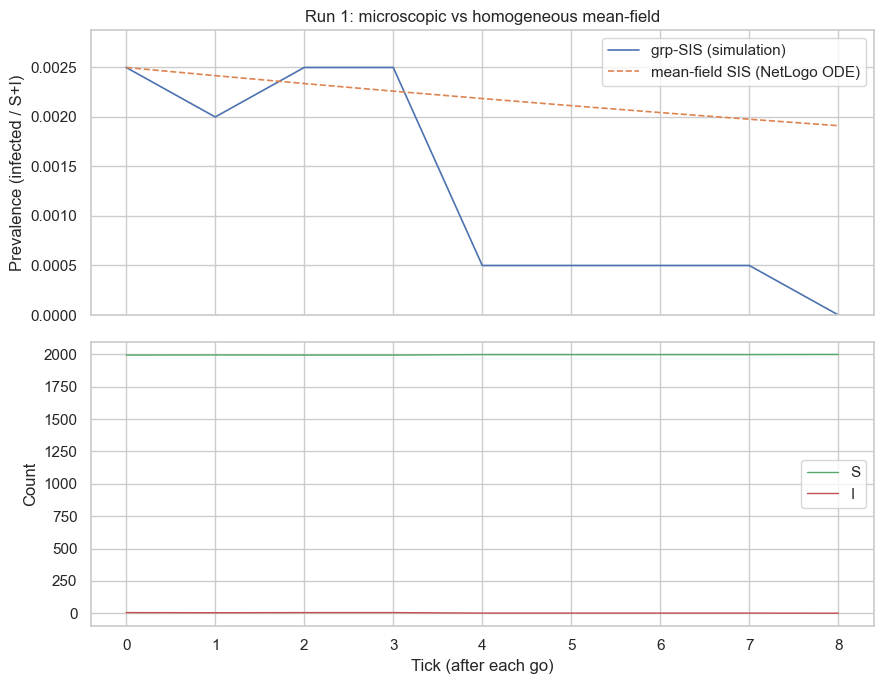

In [3]:
def plot_one_run(run_id: int | None = None) -> None:
    if run_id is None:
        run_id = int(df[run_col].min())  # BehaviorSpace exports typically use run 1, 2, … not 0
    sub = df[df[run_col] == run_id]
    if sub.empty:
        raise ValueError(f"No rows for {run_col}={run_id}")
    x = sub[step_col].to_numpy()
    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
    ax0, ax1 = axes
    ax0.plot(x, sub[grp_col], label="grp-SIS (simulation)", color="C0", lw=1.2)
    ax0.plot(x, sub[mf_col], label="mean-field SIS (NetLogo ODE)", color="C1", ls="--", lw=1.2)
    ax0.set_ylabel("Prevalence (infected / S+I)")
    ax0.set_title(f"Run {run_id}: microscopic vs homogeneous mean-field")
    ax0.legend(loc="best")
    top = max(float(sub[grp_col].max()), float(sub[mf_col].max()), 1e-6)
    ax0.set_ylim(0, top * 1.15)

    if s_col and i_col:
        ax1.plot(x, sub[s_col], label="S", color="C2", lw=1.0)
        ax1.plot(x, sub[i_col], label="I", color="C3", lw=1.0)
        ax1.set_ylabel("Count")
        ax1.legend(loc="best")
    ax1.set_xlabel("Tick (after each go)")
    plt.tight_layout()
    plt.show()


plot_one_run()

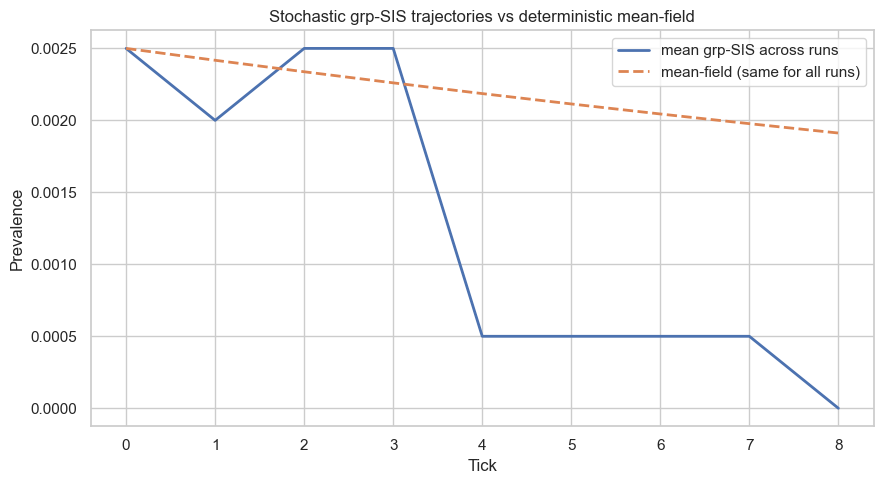

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for rid, g in df.groupby(run_col):
    ax.plot(g[step_col], g[grp_col], color="C0", alpha=0.25, lw=0.8)
mean_grp = df.groupby(step_col, sort=True)[grp_col].mean()
ax.plot(mean_grp.index, mean_grp.values, color="C0", lw=2, label="mean grp-SIS across runs")
# Mean-field curve is deterministic given k_mean; take first run's mf column (or Python ODE)
g0 = df[df[run_col] == df[run_col].min()].sort_values(step_col)
ax.plot(g0[step_col], g0[mf_col], color="C1", ls="--", lw=2, label="mean-field (same for all runs)")
ax.set_xlabel("Tick")
ax.set_ylabel("Prevalence")
ax.set_title("Stochastic grp-SIS trajectories vs deterministic mean-field")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Sanity check: Python integration matches NetLogo rho-I-mf (same Euler as update-mean-field-SIS)
nn_col = pick_column(df, "num_nodes", "num-nodes")
i0_col = pick_column(df, "initial_infected", "initial-infected")
if inf_param and rm_col and deg_col and nn_col and i0_col:
    g0 = df[df[run_col] == df[run_col].min()].sort_values(step_col)
    rowp = g0.iloc[0]
    beta = float(rowp[inf_param])
    rec_mean = float(rowp[rm_col])
    k_mean = float(rowp[deg_col])
    rho0 = float(rowp[i0_col]) / float(rowp[nn_col])
    n = len(g0)
    py_mf = discrete_mf_sis_trajectory(beta, rec_mean, k_mean, rho0, n)
    err = float(np.max(np.abs(py_mf - g0[mf_col].to_numpy())))
    print(f"max|Python MF - NetLogo rho-I-mf| = {err:.2e} (should be ~0)")
else:
    print("Skip check: need infection-prob, recovery-mean, mean degree, num-nodes, initial-infected in table")

max|Python MF - NetLogo rho-I-mf| = 8.25e-05 (should be ~0)
